# Подготовка данных растворимости в бинарных смесях

**Самостоятельный этап проекта: MixtureSolDB → проверенные таблицы для обучения.**
Основа — разделы 2.2–2.4 ВКР Георгия Новицкого: мольные доли растворителей,
температурные интервалы 1 K, пороги 20 точек на вещество и 100 на пару,
не менее четырёх внутренних составов, две известные граничные растворимости,
дополнение из BigSolDB с допуском ±3 K.

Ноутбук не обучает модели и не создаёт train/validation/test. Следующий этап должен
разбивать данные по веществам / растворителям, сохраняя все точки группы вместе.
Endpoints — известные входные величины задачи, а не объекты оценки на смесях.

## Как запустить
1. Установить зависимости в окружение Jupyter (ячейка ниже).
2. Положить `MixtureSolDB.csv` и нужную версию `BigSolDB*.csv` в `data/raw/`.
3. Указать точные пути в параметрах и выполнить **Restart Kernel → Run All**.
4. Проверить `reports/steps.csv`, `reports/curve_decisions.csv` и сводку в конце.

Исходные CSV не включены. Сеть не используется: версия базы задаётся локальным файлом,
его SHA-256 и версии библиотек записываются в манифест. Результат не обязан совпасть
с числами ВКР: здесь явные правила дедупликации и контроля конфликтующих endpoints.

In [ ]:
# Выполнить один раз при необходимости, затем перезапустить kernel:
# %pip install numpy pandas matplotlib rdkit

## 1. Параметры и методические решения

- `x1` всегда означает **мольную долю Solvent1 в смеси растворителей**;
  `logS_mix` — десятичный логарифм мольной доли растворённого вещества.
  Массовые доли переводятся через молярные массы. Объёмные / неизвестные типы
  исключаются с причиной, а не интерпретируются как мольные.
- Температура округляется к ближайшему интервалу 1 K (половины вверх).
  Исходная `Temperature_K` также сохраняется.
- Пара растворителей упорядочивается по каноническим SMILES; доли и подписи меняются
  местами одновременно. Стереохимия и многокомпонентные SMILES сохраняются;
  соли не превращаются автоматически в нейтральные молекулы.
- По умолчанию эксперимент определяется как в дипломе: вещество + пара + интервал
  температуры. Источники сохраняются. `GROUP_BY_SOURCE=True` дополнительно разделяет
  кривые по `Source` (это идентификатор публикации, не гарантированно отдельного опыта).
  `system_group_id` всегда объединяет такие кривые для будущего контроля разбиений.
- Точные повторы внутри источника удаляются. Разные измеренные значения и независимые
  источники сохраняются. Минимум четыре внутренних точки трактуется как четыре
  **различных состава** после округления до `COMPOSITION_DECIMALS`.
- Частотные пороги применяются один раз к очищенным исходным измерениям, до добавления
  endpoints. Все валидные исходные endpoints доступны для lookup, включая редкие системы.
- Приоритет: собственные endpoints кривой → endpoints других систем MixtureSolDB → BigSolDB.
  Для lookup сначала минимальное |ΔT|, при равенстве — MixtureSolDB, затем меньшая T.
- Повторные endpoints агрегируются медианой **logS**. Если их размах >0.3 logS
  (приблизительно двукратное различие S), собственная кривая исключается, а конфликтующая
  группа lookup не используется. Это дополнительное правило контроля качества,
  отсутствующее в описании диплома; `ENDPOINT_MAX_SPREAD_LOGS=None` отключает его.
- Endpoints не экстраполируются из внутренних точек и не отбираются по совпадению
  с внутренними значениями. Это сохраняет постановку прогноза неизвестной кривой.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
from datetime import datetime, timezone
from functools import lru_cache
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors

CFG = {
    "MIXTURE_PATH": "data/raw/MixtureSolDB.csv",
    "BIGSOLDB_PATH": "data/raw/BigSolDBv2.1.csv",
    "USE_BIGSOLDB": True,
    "OUTPUT_DIR": "prepared_data_v1",
    "TEMP_BIN_K": 1.0,
    "ENDPOINT_TOL_K": 3.0,
    "MIN_SOLUTE_POINTS": 20,
    "MIN_PAIR_POINTS": 100,
    "MIN_INTERNAL_COMPOSITIONS": 4,
    "GROUP_BY_SOURCE": False,
    "FRACTION_SUM_TOL": 1e-6,
    "ENDPOINT_X_TOL": 1e-8,
    "COMPOSITION_DECIMALS": 10,
    "ENDPOINT_MAX_SPREAD_LOGS": 0.3,
    "LOGS_CHECK_TOL": 1e-5,
    "SAVE_CLEANED_MEASUREMENTS": True,
    "RUN_SELF_CHECKS": True,
    "EXCLUDED_SOLVENT_NAMES": ["PEG-200", "PEG-300", "PEG-400", "PEG-600", "PEGDME 250"],
}

# Изменить эти словари, если у вашей версии CSV другие имена колонок.
# Ключ — внутреннее имя, значение — имя в исходном файле.
MIX_COLS = {
    "solute_smiles": "SMILES_Solute", "s1_smiles": "SMILES_Solvent1",
    "s2_smiles": "SMILES_Solvent2", "temperature": "Temperature_K",
    "solubility": "Solubility(mole_fraction)", "fraction1": "Fraction_Solvent1",
    "fraction2": "Fraction_Solvent2", "fraction_type": "Fraction_Type",
    "source": "Source", "solute_name": "Compound_Name",
    "s1_name": "Solvent1", "s2_name": "Solvent2", "reported_logS": "LogS(mole_fraction)",
}
BIG_COLS = {
    "solute_smiles": "SMILES_Solute", "solvent_smiles": "SMILES_Solvent",
    "temperature": "Temperature_K", "solubility": "Solubility(mole_fraction)",
    "source": "Source", "reported_logS": "LogS(mole_fraction)",
}
FRACTION_TYPES = {
    "mole": "mole", "molar": "mole", "mole fraction": "mole", "mole_fraction": "mole",
    "mass": "mass", "weight": "mass", "mass fraction": "mass", "mass_fraction": "mass",
}
display(pd.Series(CFG, name="value").to_frame())

,value
MIXTURE_PATH,data/raw/MixtureSolDB.csv
BIGSOLDB_PATH,data/raw/BigSolDBv2.1.csv
USE_BIGSOLDB,True
OUTPUT_DIR,prepared_data_v1
TEMP_BIN_K,1.0
ENDPOINT_TOL_K,3.0
MIN_SOLUTE_POINTS,20
MIN_PAIR_POINTS,100
MIN_INTERNAL_COMPOSITIONS,4
GROUP_BY_SOURCE,False


In [2]:
CFG.update({'MIXTURE_PATH': 'data/raw/MixtureSolDB/18660057/MixtureSolDB.csv', 'BIGSOLDB_PATH': 'data/raw/BigSolDB/22648301/BigSolDBv2.2.csv', 'USE_BIGSOLDB': True})

## 2. Общие функции

Фильтры возвращают исключённые строки с причиной. Проверяемые величины не
импутируются. `logS` всегда пересчитывается из положительной S ≤ 1;
расхождения с готовым логарифмом записываются отдельно.

In [3]:
def stable_id(values, prefix):
    payload = json.dumps([str(v) for v in values], ensure_ascii=False, separators=(",", ":"))
    return prefix + hashlib.sha256(payload.encode("utf-8")).hexdigest()[:24]

def json_unique(values):
    return json.dumps(sorted({str(v) for v in values if pd.notna(v)}), ensure_ascii=False)

@lru_cache(maxsize=None)
def molecule_info(smiles):
    """Канонический isomeric SMILES и MW; расчёт один раз на уникальный SMILES."""
    if not isinstance(smiles, str) or smiles.strip().lower() in {"", "nan", "none", "-"}:
        return None, np.nan
    with rdBase.BlockLogs():
        mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return None, np.nan
    mw = float(Descriptors.MolWt(mol))
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True), mw

def map_schema(raw, mapping, required):
    missing = [mapping[c] for c in required if mapping[c] not in raw.columns]
    if missing:
        raise ValueError(f"Отсутствуют обязательные колонки: {missing}. Проверьте mapping.")
    out = pd.DataFrame(index=raw.index)
    for target, source in mapping.items():
        out[target] = raw[source] if source in raw.columns else pd.NA
    return out

def filter_rows(df, keep, reason, rejected, steps):
    keep = pd.Series(keep, index=df.index).fillna(False).astype(bool)
    bad = df.loc[~keep].copy()
    if len(bad):
        bad["rejection_reason"] = reason
        rejected.append(bad)
    steps.append({"step": reason, "rows_before": len(df), "rows_after": int(keep.sum()),
                  "rows_removed": int((~keep).sum())})
    return df.loc[keep].copy()

def attach_molecule(df, raw_col, canon_col, mw_col=None):
    info = df[raw_col].map(lambda s: molecule_info(s if isinstance(s, str) else None))
    df[canon_col] = info.map(lambda v: v[0])
    if mw_col:
        df[mw_col] = info.map(lambda v: v[1])

def endpoint_side(x, tol):
    return np.select([np.isclose(x, 1., atol=tol, rtol=0),
                      np.isclose(x, 0., atol=tol, rtol=0)], [1, 2], default=0)

def concat_or_empty(items):
    return pd.concat(items, ignore_index=True, sort=False) if items else pd.DataFrame()

def spread_ok(spread, cfg):
    limit = cfg["ENDPOINT_MAX_SPREAD_LOGS"]
    return limit is None or float(spread) <= limit + 1e-12

## 3. Очистка MixtureSolDB

Порядок преобразований фиксирован: schema → диапазоны → SMILES → доли →
ориентация → идентификаторы → точные дубликаты. Исходные номера строк сохраняются
в `measurement_id` (нумерация данных с 0, без строки заголовка).

In [4]:
def clean_mixture(raw, cfg):
    required = ["solute_smiles", "s1_smiles", "s2_smiles", "temperature", "solubility",
                "fraction1", "fraction2", "fraction_type"]
    d = map_schema(raw.reset_index(drop=True), MIX_COLS, required)
    d["measurement_id"] = [f"mix:{i}" for i in range(len(d))]
    d["source"] = d["source"].fillna("unknown_source").astype(str).str.strip()
    d.loc[d["source"].eq(""), "source"] = "unknown_source"
    rejected, steps = [], []
    for c in ["temperature", "solubility", "fraction1", "fraction2", "reported_logS"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    excluded = {s.casefold() for s in cfg["EXCLUDED_SOLVENT_NAMES"]}
    bad_name = d["s1_name"].fillna("").str.strip().str.casefold().isin(excluded) | d["s2_name"].fillna("").str.strip().str.casefold().isin(excluded)
    d = filter_rows(d, ~bad_name, "excluded_polymeric_solvent", rejected, steps)
    valid = np.isfinite(d["temperature"]) & d["temperature"].gt(0)
    valid &= np.isfinite(d["solubility"]) & d["solubility"].gt(0) & d["solubility"].le(1)
    d = filter_rows(d, valid, "invalid_temperature_or_solubility", rejected, steps)
    for raw_col, canon, mw in [("solute_smiles", "canon_SMILES_Solute", "MW_Solute"),
                               ("s1_smiles", "canon_SMILES_Solvent1", "MW_Solvent1"),
                               ("s2_smiles", "canon_SMILES_Solvent2", "MW_Solvent2")]:
        attach_molecule(d, raw_col, canon, mw)
    valid = d[["canon_SMILES_Solute", "canon_SMILES_Solvent1", "canon_SMILES_Solvent2"]].notna().all(axis=1)
    valid &= d[["MW_Solute", "MW_Solvent1", "MW_Solvent2"]].gt(0).all(axis=1)
    d = filter_rows(d, valid, "invalid_SMILES_or_MW", rejected, steps)
    d = filter_rows(d, d["canon_SMILES_Solvent1"].ne(d["canon_SMILES_Solvent2"]),
                    "identical_solvents", rejected, steps)
    d["fraction_type_normalized"] = d["fraction_type"].astype(str).str.strip().str.lower().map(FRACTION_TYPES)
    d = filter_rows(d, d["fraction_type_normalized"].notna(), "unsupported_fraction_type", rejected, steps)
    f1, f2 = d["fraction1"], d["fraction2"]
    valid = np.isfinite(f1) & np.isfinite(f2) & f1.between(0, 1) & f2.between(0, 1)
    valid &= np.isclose(f1 + f2, 1., atol=cfg["FRACTION_SUM_TOL"], rtol=0)
    d = filter_rows(d, valid, "invalid_fractions", rejected, steps)
    # Нормируем только доли, прошедшие проверку суммы.
    f1 = d["fraction1"] / (d["fraction1"] + d["fraction2"])
    f2 = 1. - f1
    x_mass = (f1 / d["MW_Solvent1"]) / (f1 / d["MW_Solvent1"] + f2 / d["MW_Solvent2"])
    d["x1"] = np.where(d["fraction_type_normalized"].eq("mass"), x_mass, f1)
    d["x2"] = 1. - d["x1"]
    # Оригинальные fraction1/fraction2 и raw SMILES остаются для аудита.
    swap = d["canon_SMILES_Solvent1"] > d["canon_SMILES_Solvent2"]
    for a, b in [("canon_SMILES_Solvent1", "canon_SMILES_Solvent2"),
                 ("MW_Solvent1", "MW_Solvent2"), ("s1_name", "s2_name"), ("x1", "x2")]:
        d.loc[swap, [a, b]] = d.loc[swap, [b, a]].to_numpy()
    d["solvents_were_swapped"] = swap
    d["Temperature_K"] = d["temperature"]
    d["Temperature_bin_K"] = np.floor(d["Temperature_K"] / cfg["TEMP_BIN_K"] + .5) * cfg["TEMP_BIN_K"]
    d["logS_mix"] = np.log10(d["solubility"])
    mismatch = d["reported_logS"].notna() & ~np.isclose(d["reported_logS"], d["logS_mix"], atol=cfg["LOGS_CHECK_TOL"], rtol=0)
    logs_audit = d.loc[mismatch, ["measurement_id", "reported_logS", "logS_mix", "source"]].copy()
    d["endpoint_side"] = endpoint_side(d["x1"], cfg["ENDPOINT_X_TOL"])
    d.loc[d["endpoint_side"].eq(1), ["x1", "x2"]] = [1., 0.]
    d.loc[d["endpoint_side"].eq(2), ["x1", "x2"]] = [0., 1.]
    d["is_internal_point"] = d["endpoint_side"].eq(0)
    d["composition_key"] = d["x1"].round(cfg["COMPOSITION_DECIMALS"])
    d["solvent_pair_id"] = [stable_id(v, "pair:") for v in d[["canon_SMILES_Solvent1", "canon_SMILES_Solvent2"]].itertuples(index=False, name=None)]
    system_cols = ["canon_SMILES_Solute", "canon_SMILES_Solvent1", "canon_SMILES_Solvent2", "Temperature_bin_K"]
    d["system_group_id"] = [stable_id(v, "system:") for v in d[system_cols].itertuples(index=False, name=None)]
    group_cols = system_cols + (["source"] if cfg["GROUP_BY_SOURCE"] else [])
    d["experiment_id"] = [stable_id(v, "curve:") for v in d[group_cols].itertuples(index=False, name=None)]
    # Дедупликация без округления S / исходной T; точные измерения разных источников не удаляются.
    dedup_cols = system_cols[:3] + ["Temperature_K", "x1", "logS_mix", "source"]
    d = filter_rows(d, ~d.duplicated(dedup_cols), "exact_duplicate_within_source", rejected, steps)
    return d.reset_index(drop=True), {"rejected_measurements": concat_or_empty(rejected),
                                    "steps": pd.DataFrame(steps), "logS_mismatches": logs_audit}

## 4. Очистка BigSolDB и lookup граничных значений

BigSolDB должен содержать растворимость именно в **мольной доле**, не mol/L.
Несколько измерений при одной T агрегируются; размах, число измерений и источники
сохраняются. Поиск выполняется в индексированном словаре по веществу и растворителю.

In [5]:
def clean_big(raw, cfg):
    required = ["solute_smiles", "solvent_smiles", "temperature", "solubility"]
    d = map_schema(raw.reset_index(drop=True), BIG_COLS, required)
    d["measurement_id"] = [f"big:{i}" for i in range(len(d))]
    d["source"] = d["source"].fillna("unknown_source").astype(str).str.strip()
    rejected, steps = [], []
    for c in ["temperature", "solubility", "reported_logS"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    valid = np.isfinite(d["temperature"]) & d["temperature"].gt(0)
    valid &= np.isfinite(d["solubility"]) & d["solubility"].gt(0) & d["solubility"].le(1)
    d = filter_rows(d, valid, "big_invalid_temperature_or_solubility", rejected, steps)
    attach_molecule(d, "solute_smiles", "canon_SMILES_Solute")
    attach_molecule(d, "solvent_smiles", "canon_SMILES_Solvent")
    d = filter_rows(d, d[["canon_SMILES_Solute", "canon_SMILES_Solvent"]].notna().all(axis=1),
                    "big_invalid_SMILES", rejected, steps)
    d["Temperature_K"] = d["temperature"]
    d["logS_endpoint"] = np.log10(d["solubility"])
    mismatch = d["reported_logS"].notna() & ~np.isclose(d["reported_logS"], d["logS_endpoint"], atol=cfg["LOGS_CHECK_TOL"], rtol=0)
    logs_audit = d.loc[mismatch, ["measurement_id", "reported_logS", "logS_endpoint", "source"]].copy()
    cols = ["canon_SMILES_Solute", "canon_SMILES_Solvent", "Temperature_K", "logS_endpoint", "source"]
    d = filter_rows(d, ~d.duplicated(cols), "big_exact_duplicate_within_source", rejected, steps)
    return d.reset_index(drop=True), {"rejected_bigsoldb": concat_or_empty(rejected),
                                    "big_steps": pd.DataFrame(steps), "big_logS_mismatches": logs_audit}

def build_endpoint_lookup(cleaned, big, cfg):
    pure = cleaned.loc[~cleaned["is_internal_point"]].copy()
    pure["canon_SMILES_Solvent"] = np.where(pure["endpoint_side"].eq(1), pure["canon_SMILES_Solvent1"], pure["canon_SMILES_Solvent2"])
    pure["logS_endpoint"] = pure["logS_mix"]
    pure["dataset"] = "MixtureSolDB"
    cols = ["canon_SMILES_Solute", "canon_SMILES_Solvent", "Temperature_K", "logS_endpoint", "source", "measurement_id", "dataset"]
    parts = [pure[cols]]
    if big is not None and len(big):
        b = big.copy()
        b["dataset"] = "BigSolDB"
        parts.append(b[cols])
    points = pd.concat(parts, ignore_index=True)
    # Один endpoint может повторяться в разных бинарных системах одной статьи.
    # При lookup такая копия не должна давать дополнительный вес в медиане.
    points = points.drop_duplicates(["canon_SMILES_Solute", "canon_SMILES_Solvent",
                                     "Temperature_K", "logS_endpoint", "source", "dataset"])
    keys = ["canon_SMILES_Solute", "canon_SMILES_Solvent", "Temperature_K", "dataset"]
    lookup = points.groupby(keys, dropna=False, sort=True).agg(
        logS_endpoint=("logS_endpoint", "median"), logS_min=("logS_endpoint", "min"),
        logS_max=("logS_endpoint", "max"), n_measurements=("measurement_id", "size"),
        sources=("source", json_unique), measurement_ids=("measurement_id", json_unique)).reset_index()
    lookup["spread_logS"] = lookup["logS_max"] - lookup["logS_min"]
    lookup["usable"] = lookup["spread_logS"].map(lambda v: spread_ok(v, cfg))
    lookup["dataset_priority"] = lookup["dataset"].map({"MixtureSolDB": 0, "BigSolDB": 1})
    usable = lookup.loc[lookup["usable"]].copy()
    index = {(s, v): g.reset_index(drop=True) for (s, v), g in usable.groupby(["canon_SMILES_Solute", "canon_SMILES_Solvent"], sort=False)}
    return lookup, index

def nearest_endpoint(index, solute, solvent, temperature, cfg):
    candidates = index.get((solute, solvent))
    if candidates is None:
        return None
    c = candidates.copy()
    c["delta_K"] = c["Temperature_K"] - temperature
    c = c.loc[c["delta_K"].abs().le(cfg["ENDPOINT_TOL_K"] + 1e-12)]
    if c.empty:
        return None
    c["abs_delta_K"] = c["delta_K"].abs()
    return c.sort_values(["abs_delta_K", "dataset_priority", "Temperature_K"], kind="stable").iloc[0].to_dict()

## 5. Частотные фильтры, кривые и присоединение endpoints

Таблица `curves` содержит также исключённые кривые и причины исключения.
Граничные точки используются сначала из самой кривой; endpoint температуры
из соседнего интервала никогда не заменяет имеющееся собственное измерение.
При конфликте собственных endpoints кривая исключается целиком.

In [6]:
class NoAcceptedCurvesError(ValueError):
    def __init__(self, curves):
        super().__init__("Нет принятых кривых. Проверьте входные данные и пороги.")
        self.curves = curves

def prepare_tables(cleaned, endpoint_index, cfg):
    d = cleaned.copy()
    solute_n = d.groupby("canon_SMILES_Solute")["measurement_id"].transform("size")
    pair_n = d.groupby("solvent_pair_id")["measurement_id"].transform("size")
    d["passes_solute_frequency"] = solute_n.ge(cfg["MIN_SOLUTE_POINTS"])
    d["passes_pair_frequency"] = pair_n.ge(cfg["MIN_PAIR_POINTS"])
    curve_rows, endpoint_rows = [], []
    for experiment_id, g in d.groupby("experiment_id", sort=True):
        first = g.iloc[0]
        record = {c: first[c] for c in ["experiment_id", "system_group_id", "solvent_pair_id",
                  "canon_SMILES_Solute", "canon_SMILES_Solvent1", "canon_SMILES_Solvent2", "Temperature_bin_K"]}
        record.update(n_measurements=len(g), n_internal_measurements=int(g["is_internal_point"].sum()),
                      n_internal_compositions=g.loc[g["is_internal_point"], "composition_key"].nunique(),
                      Temperature_min_K=float(g["Temperature_K"].min()), Temperature_max_K=float(g["Temperature_K"].max()),
                      sources=json_unique(g["source"]))
        reasons = []
        if not g["passes_solute_frequency"].all(): reasons.append("rare_solute")
        if not g["passes_pair_frequency"].all(): reasons.append("rare_solvent_pair")
        if record["n_internal_compositions"] < cfg["MIN_INTERNAL_COMPOSITIONS"]:
            reasons.append("too_few_internal_compositions")
        # Для заведомо исключённых кривых lookup не нужен.
        if not reasons:
            for side in [1, 2]:
                own = g.loc[g["endpoint_side"].eq(side)]
                if len(own):
                    spread = float(own["logS_mix"].max() - own["logS_mix"].min())
                    if not spread_ok(spread, cfg):
                        reasons.append(f"conflicting_own_endpoint_{side}")
                        continue
                    ep = {"logS_endpoint": float(own["logS_mix"].median()),
                          "Temperature_K": float(own["Temperature_K"].median()), "dataset": "MixtureSolDB",
                          "sources": json_unique(own["source"]), "measurement_ids": json_unique(own["measurement_id"]),
                          "n_measurements": len(own), "spread_logS": spread}
                    origin = "own_curve"
                else:
                    ep = nearest_endpoint(endpoint_index, first["canon_SMILES_Solute"],
                                          first[f"canon_SMILES_Solvent{side}"], first["Temperature_bin_K"], cfg)
                    origin = "lookup"
                if ep is None:
                    reasons.append(f"missing_endpoint_{side}")
                    continue
                record[f"logS{side}"] = ep["logS_endpoint"]
                record[f"endpoint{side}_origin"] = origin
                record[f"endpoint{side}_dataset"] = ep["dataset"]
                record[f"endpoint{side}_temperature_K"] = ep["Temperature_K"]
                record[f"endpoint{side}_delta_K"] = ep["Temperature_K"] - first["Temperature_bin_K"]
                record[f"endpoint{side}_sources"] = ep["sources"]
                record[f"endpoint{side}_measurement_ids"] = ep["measurement_ids"]
                record[f"endpoint{side}_n_measurements"] = ep["n_measurements"]
                record[f"endpoint{side}_spread_logS"] = ep["spread_logS"]
                endpoint_rows.append({"experiment_id": experiment_id, "side": side, "origin": origin,
                                      "delta_K": record[f"endpoint{side}_delta_K"], **ep})
        record["accepted"] = not reasons
        record["exclusion_reasons"] = ";".join(reasons)
        curve_rows.append(record)
    curves = pd.DataFrame(curve_rows)
    if curves.empty or not curves["accepted"].any():
        raise NoAcceptedCurvesError(curves)
    accepted = curves.loc[curves["accepted"]].copy()
    ep_cols = [c for c in accepted if c.startswith("endpoint") or c in ["experiment_id", "logS1", "logS2"]]
    internal = d.loc[d["is_internal_point"] & d["experiment_id"].isin(accepted["experiment_id"])].copy()
    internal = internal.merge(accepted[ep_cols], on="experiment_id", how="left", validate="many_to_one")
    internal["row_origin"] = "measured_internal"
    internal["Source"] = internal["source"]
    # В ML-таблицу не переносим дубли target / сырые доли / служебные флаги очистки.
    # Все исходные поля доступны в cleaned_measurements.csv.
    internal_cols = ["experiment_id", "system_group_id", "measurement_id", "solvent_pair_id",
                     "canon_SMILES_Solute", "canon_SMILES_Solvent1", "canon_SMILES_Solvent2",
                     "solute_name", "s1_name", "s2_name", "Temperature_K", "Temperature_bin_K",
                     "x1", "x2", "composition_key", "logS_mix", "logS1", "logS2",
                     "MW_Solute", "MW_Solvent1", "MW_Solvent2", "is_internal_point",
                     "row_origin", "Source", "endpoint_side"]
    internal_cols += [c for c in ep_cols if c not in internal_cols]
    internal = internal[internal_cols].copy()
    # Полная таблица: исходные внутренние измерения + ровно 2 согласованных endpoints на кривую.
    # Не копируем неизвестные свойства / исходные fraction-поля в синтетические endpoint-строки.
    canonical_endpoints = []
    for _, c in accepted.iterrows():
        for side, x in [(1, 1.), (2, 0.)]:
            r = {k: c[k] for k in ["experiment_id", "system_group_id", "solvent_pair_id", "canon_SMILES_Solute",
                                  "canon_SMILES_Solvent1", "canon_SMILES_Solvent2", "Temperature_bin_K"]}
            r.update({k: c[k] for k in ep_cols if k != "experiment_id"})
            r.update(x1=x, x2=1.-x, logS_mix=c[f"logS{side}"], is_internal_point=False,
                     Temperature_K=c[f"endpoint{side}_temperature_K"], row_origin="endpoint_reference",
                     measurement_id=f"reference:{c['experiment_id']}:{side}",
                     Source=c[f"endpoint{side}_sources"], endpoint_side=side)
            canonical_endpoints.append(r)
    full = pd.concat([internal, pd.DataFrame(canonical_endpoints)], ignore_index=True, sort=False)
    for frame in [internal, full]:
        frame["S_mix"] = np.power(10., frame["logS_mix"])
        frame["logS_base"] = frame["x1"] * frame["logS1"] + frame["x2"] * frame["logS2"]
        frame["delta_logS"] = frame["logS_mix"] - frame["logS_base"]
        frame["x1_x2"] = frame["x1"] * frame["x2"]
        frame.sort_values(["experiment_id", "x1", "measurement_id"], inplace=True)
        frame.reset_index(drop=True, inplace=True)
    endpoints = pd.DataFrame(endpoint_rows)
    endpoints = endpoints.loc[endpoints["experiment_id"].isin(accepted["experiment_id"])].reset_index(drop=True)
    return internal, full, curves, endpoints

## 6. Проверки результата

Проверяются диапазоны, единая ориентация, постоянство endpoints внутри кривой,
различные составы, согласованность бейзлайна на границах и температурный допуск lookup.
Нет обучения, отбора дескрипторов или использования коэффициентов, найденных по кривой.

In [7]:
def validate_tables(internal, full, curves, endpoints, cfg):
    assert len(internal) > 0
    assert internal["is_internal_point"].all()
    assert internal["x1"].between(0, 1, inclusive="neither").all()
    assert np.allclose(internal["x1"] + internal["x2"], 1., atol=1e-12, rtol=0)
    assert np.isfinite(internal[["Temperature_bin_K", "logS_mix", "logS1", "logS2"]]).all().all()
    assert internal["S_mix"].between(0, 1, inclusive="right").all()
    assert (internal["canon_SMILES_Solvent1"] < internal["canon_SMILES_Solvent2"]).all()
    assert internal.groupby("experiment_id")[["logS1", "logS2", "system_group_id"]].nunique().eq(1).all().all()
    assert internal.groupby("experiment_id")["composition_key"].nunique().ge(cfg["MIN_INTERNAL_COMPOSITIONS"]).all()
    accepted = curves.loc[curves["accepted"], "experiment_id"]
    assert set(internal["experiment_id"]) == set(accepted)
    edges = full.loc[~full["is_internal_point"]]
    assert edges.groupby("experiment_id").size().eq(2).all()
    assert np.allclose(edges["delta_logS"], 0., atol=1e-12, rtol=0)
    assert endpoints.loc[endpoints["origin"].eq("lookup"), "delta_K"].abs().le(cfg["ENDPOINT_TOL_K"] + 1e-12).all()
    # Бейзлайн инвариантен при перестановке растворителей.
    reverse = internal["x2"] * internal["logS2"] + internal["x1"] * internal["logS1"]
    assert np.allclose(internal["logS_base"], reverse)
    print("Проверки итоговых таблиц пройдены.")

## 7. Автоматические контрольные примеры

Маленькие искусственные данные проверяют ключевые преобразования до чтения реальных баз.
Эти проверки не являются расчётом метрик исследования. Они не записываются в итоговый датасет.

In [8]:
def run_self_checks():
    cfg = dict(CFG, MIN_SOLUTE_POINTS=1, MIN_PAIR_POINTS=1, MIN_INTERNAL_COMPOSITIONS=4)
    def row(solute="CC", x=.2, T=298.15, S=.01, source="paper:A", a="O", b="CCO", kind="mole"):
        return {"SMILES_Solute": solute, "SMILES_Solvent1": a, "SMILES_Solvent2": b,
                "Temperature_K": T, "Solubility(mole_fraction)": S,
                "Fraction_Solvent1": x, "Fraction_Solvent2": 1-x, "Fraction_Type": kind,
                "Source": source, "Solvent1": "water" if a == "O" else "ethanol",
                "Solvent2": "ethanol" if b == "CCO" else "water"}
    rows = [row(x=x) for x in [0., .2, .4, .6, .8, 1.]]
    rows += [rows[1].copy(), row(x=.3, kind="volume"), row(a="invalid_smiles")]
    clean, audit = clean_mixture(pd.DataFrame(rows), cfg)
    assert len(clean) == 6 and len(audit["rejected_measurements"]) == 3
    assert clean["solvents_were_swapped"].all()
    assert np.allclose(clean["x1"].sort_values(), [0., .2, .4, .6, .8, 1.])
    # Одинаковая физическая смесь в двух ориентациях даёт одну систему и одинаковую долю.
    reversed_raw = pd.DataFrame([row(x=.3), row(x=.7, a="CCO", b="O", source="paper:B")])
    r, _ = clean_mixture(reversed_raw, cfg)
    assert r["system_group_id"].nunique() == 1 and np.allclose(r["x1"], .7)
    mass, _ = clean_mixture(pd.DataFrame([row(x=.5, kind="mass")]), cfg)
    mw_water, mw_ethanol = molecule_info("O")[1], molecule_info("CCO")[1]
    expected = (.5 / mw_ethanol) / (.5 / mw_ethanol + .5 / mw_water)
    assert np.isclose(mass.iloc[0]["x1"], expected)
    lookup, idx = build_endpoint_lookup(clean, None, cfg)
    i, f, c, e = prepare_tables(clean, idx, cfg)
    validate_tables(i, f, c, e, cfg)
    assert len(i) == 4 and len(f) == 6 and e["origin"].eq("own_curve").all()
    # Без собственных endpoints обе границы берутся из BigSolDB; ±3 K включительно.
    no_edges = clean.loc[clean["is_internal_point"]].copy()
    big_raw = pd.DataFrame([{"SMILES_Solute": "CC", "SMILES_Solvent": s,
                             "Temperature_K": 301., "Solubility(mole_fraction)": .02,
                             "Source": "paper:big"} for s in ["O", "CCO"]])
    b, _ = clean_big(big_raw, cfg)
    _, idx2 = build_endpoint_lookup(no_edges, b, cfg)
    i2, f2, c2, e2 = prepare_tables(no_edges, idx2, cfg)
    validate_tables(i2, f2, c2, e2, cfg)
    assert e2["dataset"].eq("BigSolDB").all() and e2["delta_K"].eq(3.).all()
    assert nearest_endpoint(idx2, "CC", "O", 297.999, cfg) is None
    # Ближайшая T важнее типа базы; при равной T побеждает MixtureSolDB.
    _, combined = build_endpoint_lookup(clean, b, cfg)
    assert nearest_endpoint(combined, "CC", "O", 298., cfg)["dataset"] == "MixtureSolDB"
    # Сильный конфликт собственного endpoint исключает только проблемную кривую.
    conflict = pd.DataFrame([row(x=x) for x in [0., .2, .4, .6, .8, 1.]] + [row(x=0., S=.2, source="paper:B")]
                            + [row(solute="CCC", x=x) for x in [0., .2, .4, .6, .8, 1.]])
    cc, _ = clean_mixture(conflict, cfg)
    _, ix = build_endpoint_lookup(cc, None, cfg)
    ii, ff, decisions, ee = prepare_tables(cc, ix, cfg)
    assert decisions["accepted"].sum() == 1
    assert decisions.loc[~decisions["accepted"], "exclusion_reasons"].str.contains("conflicting_own_endpoint").all()
    validate_tables(ii, ff, decisions, ee, cfg)
    # Source разделяет кривые, но не system_group_id.
    grouped, _ = clean_mixture(reversed_raw, dict(cfg, GROUP_BY_SOURCE=True))
    assert grouped["experiment_id"].nunique() == 2 and grouped["system_group_id"].nunique() == 1
    print("Контрольные примеры пройдены: доли, ориентация, дубликаты, lookup, конфликты и группировка.")

if CFG["RUN_SELF_CHECKS"]:
    run_self_checks()

Проверки итоговых таблиц пройдены.
Проверки итоговых таблиц пройдены.
Проверки итоговых таблиц пройдены.
Контрольные примеры пройдены: доли, ориентация, дубликаты, lookup, конфликты и группировка.


## 8. Загрузка реальных данных

Если `USE_BIGSOLDB=True`, отсутствие файла приводит к понятной ошибке.
Для запуска без внешней базы установите `USE_BIGSOLDB=False`: кривые без двух
доступных MixtureSolDB endpoints будут исключены. Автоматического скачивания нет.

In [9]:
if CFG["TEMP_BIN_K"] <= 0 or CFG["ENDPOINT_TOL_K"] < 0:
    raise ValueError("TEMP_BIN_K должен быть >0, ENDPOINT_TOL_K — >=0.")
for key in ["MIN_SOLUTE_POINTS", "MIN_PAIR_POINTS", "MIN_INTERNAL_COMPOSITIONS"]:
    if CFG[key] < 1:
        raise ValueError(f"{key} должен быть >=1")

mix_path = Path(CFG["MIXTURE_PATH"]).expanduser()
big_path = Path(CFG["BIGSOLDB_PATH"]).expanduser()
if not mix_path.is_file():
    raise FileNotFoundError(f"Нет {mix_path.resolve()}. Укажите путь к MixtureSolDB в CFG.")
if CFG["USE_BIGSOLDB"] and not big_path.is_file():
    raise FileNotFoundError(f"Нет {big_path.resolve()}. Укажите путь или USE_BIGSOLDB=False.")

mixture_raw = pd.read_csv(mix_path, low_memory=False)
bigsoldb_raw = pd.read_csv(big_path, low_memory=False) if CFG["USE_BIGSOLDB"] else None
print("MixtureSolDB:", mixture_raw.shape)
display(mixture_raw.head())
display(mixture_raw[MIX_COLS["fraction_type"]].value_counts(dropna=False).rename("n").to_frame())
if bigsoldb_raw is not None:
    print("BigSolDB:", bigsoldb_raw.shape)
    display(bigsoldb_raw.head())

MixtureSolDB: (175166, 19)


,SMILES_Solute,Temperature_K,Solubility(mole_fraction),LogS(mole_fraction),Solubility(g/100g),LogS(g/100g),Solvent1,Solvent2,SMILES_Solvent1,SMILES_Solvent2,Fraction_Solvent1,Fraction_Solvent2,Fraction_Type,Compound_Name,CAS,PubChem_CID,FDA_Approved,Source,IsPureSolventEndpoint
0,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,278.15,0.0872,-1.059484,212.339615,2.327031,acetonitrile,water,CC#N,O,0.0,1.0,mole,Rivastigmine tartrate,129101-54-8,6918078.0,True,10.1007/s10973-018-7684-y,True
1,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,283.15,0.0983,-1.007446,242.315737,2.384382,acetonitrile,water,CC#N,O,0.0,1.0,mole,Rivastigmine tartrate,129101-54-8,6918078.0,True,10.1007/s10973-018-7684-y,True
2,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,288.15,0.1126,-0.948462,282.038981,2.450309,acetonitrile,water,CC#N,O,0.0,1.0,mole,Rivastigmine tartrate,129101-54-8,6918078.0,True,10.1007/s10973-018-7684-y,True
3,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,293.15,0.1287,-0.890421,328.322771,2.516301,acetonitrile,water,CC#N,O,0.0,1.0,mole,Rivastigmine tartrate,129101-54-8,6918078.0,True,10.1007/s10973-018-7684-y,True
4,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,298.15,0.1469,-0.832978,382.747203,2.582912,acetonitrile,water,CC#N,O,0.0,1.0,mole,Rivastigmine tartrate,129101-54-8,6918078.0,True,10.1007/s10973-018-7684-y,True


,n
Fraction_Type,
mass,91463
mole,83703


BigSolDB: (125752, 14)


,SMILES_Solute,Temperature_K,Solvent,SMILES_Solvent,Solubility(mole_fraction),Solubility(mol/L),LogS(mol/L),LogS(mole_fraction),Compound_Name,CAS,PubChem_CID,FDA_Approved,Source,solid_form_label
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,311.25,ethanol,CCO,0.0006,0.010083,-1.996419,-3.221849,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573,NaN
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,314.65,ethanol,CCO,0.0012,0.020100,-1.696799,-2.920819,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573,NaN
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,319.15,ethanol,CCO,0.0020,0.033356,-1.476824,-2.698970,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573,NaN
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,322.15,ethanol,CCO,0.0050,0.083356,-1.079064,-2.301030,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573,NaN
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,324.15,ethanol,CCO,0.0139,0.233286,-0.632111,-1.856985,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573,NaN


## 9. Выполнение подготовки

Для диагностики пустого результата доступны `cleaned` и `endpoint_lookup`.
Низкие частотные пороги допустимы для проверки кода; параметры научного расчёта
фиксируйте до сравнения моделей. Не подбирайте фильтры по тестовым метрикам.

In [10]:
cleaned, reports = clean_mixture(mixture_raw, CFG)
if cleaned.empty:
    raise ValueError("Очистка удалила все измерения. Проверьте mapping и reports.")
big_cleaned = None
if bigsoldb_raw is not None:
    big_cleaned, big_reports = clean_big(bigsoldb_raw, CFG)
    reports.update(big_reports)
endpoint_lookup, endpoint_index = build_endpoint_lookup(cleaned, big_cleaned, CFG)
try:
    internal, full, curves, endpoints = prepare_tables(cleaned, endpoint_index, CFG)
except NoAcceptedCurvesError as error:
    diagnostic_dir = Path(CFG["OUTPUT_DIR"]) / "reports"
    diagnostic_dir.mkdir(parents=True, exist_ok=True)
    error.curves.to_csv(diagnostic_dir / "curve_decisions.csv", index=False)
    reports["steps"].to_csv(diagnostic_dir / "steps.csv", index=False)
    endpoint_lookup.to_csv(diagnostic_dir / "endpoint_lookup.csv", index=False)
    raise ValueError(f"{error} Диагностика: {diagnostic_dir.resolve()}") from error
validate_tables(internal, full, curves, endpoints, CFG)
print(f"Очищенные исходные измерения: {len(cleaned):,}")
print(f"Принятые кривые: {curves['accepted'].sum():,} из {len(curves):,}")
print(f"Внутренние измерения: {len(internal):,}; полная таблица: {len(full):,}")
display(internal[["experiment_id", "Temperature_bin_K", "x1", "logS_mix", "logS1", "logS2", "logS_base", "delta_logS"]].head())

Проверки итоговых таблиц пройдены.
Очищенные исходные измерения: 173,716
Принятые кривые: 12,703 из 23,625
Внутренние измерения: 99,852; полная таблица: 125,258


,experiment_id,Temperature_bin_K,x1,logS_mix,logS1,logS2,logS_base,delta_logS
0,curve:0011fd8f368080ea2f2345a9,293.0,0.033316,-2.762708,-0.790485,-3.571056,-3.478419,0.715711
1,curve:0011fd8f368080ea2f2345a9,293.0,0.071964,-2.366229,-0.790485,-3.571056,-3.370956,1.004727
2,curve:0011fd8f368080ea2f2345a9,293.0,0.117335,-2.065653,-0.790485,-3.571056,-3.244798,1.179145
3,curve:0011fd8f368080ea2f2345a9,293.0,0.171351,-1.841035,-0.790485,-3.571056,-3.094602,1.253567
4,curve:0011fd8f368080ea2f2345a9,293.0,0.236744,-1.615288,-0.790485,-3.571056,-2.912774,1.297485


## 10. Сводки и визуальный контроль

Метрики обученных моделей здесь не рассчитываются. Для оценки бейзлайна на будущих
validation/test нужно использовать их фиксированные разбиения, не эту общую таблицу.

,n
raw_mixture_rows,175166
cleaned_mixture_rows,173716
candidate_curves,23625
accepted_curves,12703
internal_rows,99852
full_rows,125258
solutes,582
solvent_pairs,158
solvents,51
raw_big_rows,125752


,step,rows_before,rows_after,rows_removed
0,excluded_polymeric_solvent,175166,173716,1450
1,invalid_temperature_or_solubility,173716,173716,0
2,invalid_SMILES_or_MW,173716,173716,0
3,identical_solvents,173716,173716,0
4,unsupported_fraction_type,173716,173716,0
5,invalid_fractions,173716,173716,0
6,exact_duplicate_within_source,173716,173716,0


,n_curves
exclusion_reasons,
too_few_internal_compositions,5460
missing_endpoint_2,2546
rare_solvent_pair,2518
missing_endpoint_1,2031
rare_solute,38
conflicting_own_endpoint_1,32
conflicting_own_endpoint_2,4


n_endpoints
origin    dataset                  
lookup    BigSolDB             3588
          MixtureSolDB          945
own_curve MixtureSolDB        20873

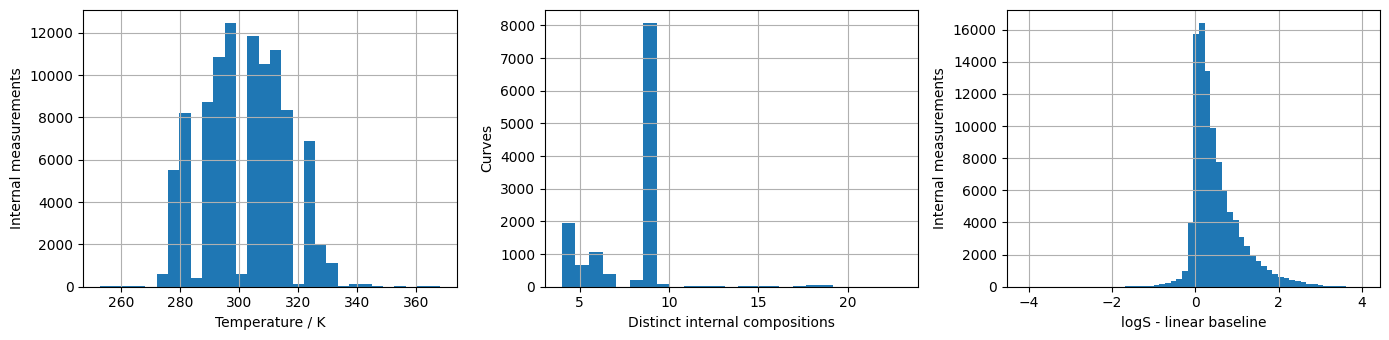

In [11]:
summary = {
    "raw_mixture_rows": len(mixture_raw), "cleaned_mixture_rows": len(cleaned),
    "candidate_curves": len(curves), "accepted_curves": int(curves["accepted"].sum()),
    "internal_rows": len(internal), "full_rows": len(full),
    "solutes": internal["canon_SMILES_Solute"].nunique(),
    "solvent_pairs": internal["solvent_pair_id"].nunique(),
    "solvents": pd.concat([internal["canon_SMILES_Solvent1"], internal["canon_SMILES_Solvent2"]]).nunique(),
    "raw_big_rows": 0 if bigsoldb_raw is None else len(bigsoldb_raw),
    "accepted_lookup_endpoints": int(endpoints["origin"].eq("lookup").sum()),
    "accepted_big_endpoints": int(endpoints["dataset"].eq("BigSolDB").sum()),
    "conflicting_lookup_groups": int((~endpoint_lookup["usable"]).sum()),
}
display(pd.Series(summary, name="n").to_frame())
display(reports["steps"])
reason_counts = curves.loc[~curves["accepted"], "exclusion_reasons"].str.split(";").explode().value_counts().rename("n_curves").to_frame()
display(reason_counts)
display(endpoints.groupby(["origin", "dataset"]).size().rename("n_endpoints").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
internal["Temperature_bin_K"].hist(bins=30, ax=axes[0])
axes[0].set(xlabel="Temperature / K", ylabel="Internal measurements")
curves.loc[curves["accepted"], "n_internal_compositions"].hist(bins=25, ax=axes[1])
axes[1].set(xlabel="Distinct internal compositions", ylabel="Curves")
internal["delta_logS"].hist(bins=60, ax=axes[2])
axes[2].set(xlabel="logS - linear baseline", ylabel="Internal measurements")
fig.tight_layout()
plt.show()

## 11. Сохранение результатов и манифеста

| Файл | Назначение |
|---|---|
| `dataset_internal.csv` | Только измеренные внутренние точки: основная таблица для обучения и оценки |
| `dataset_full.csv` | Внутренние точки + две согласованные граничные записи на кривую |
| `curves.csv` | Все кандидаты, endpoints, причины исключения и флаг accepted |
| `endpoint_assignments.csv` | Происхождение каждой принятой граничной растворимости |
| `endpoint_lookup.csv` | Кандидаты lookup, размахи и пригодность |
| `cleaned_measurements.csv` | Валидные исходные измерения до частотных фильтров (опционально) |
| `reports/*.csv` | Исключённые измерения, дубликаты, расхождения logS, решения по кривым |
| `manifest.json` | Параметры, SHA-256 файлов, версии библиотек, сводка |

CSV записываются в UTF-8. Повторный запуск в тот же каталог обновляет результаты;
для другого протокола используйте отдельный `OUTPUT_DIR`.

In [12]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

out_dir = Path(CFG["OUTPUT_DIR"])
report_dir = out_dir / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
tables = {"dataset_internal": internal, "dataset_full": full, "curves": curves,
          "endpoint_assignments": endpoints, "endpoint_lookup": endpoint_lookup}
if CFG["SAVE_CLEANED_MEASUREMENTS"]:
    tables["cleaned_measurements"] = cleaned
for name, table in tables.items():
    table.to_csv(out_dir / f"{name}.csv", index=False, encoding="utf-8")
reports["curve_decisions"] = curves
reports["excluded_curve_measurements"] = cleaned.loc[~cleaned["experiment_id"].isin(internal["experiment_id"])].merge(
    curves[["experiment_id", "exclusion_reasons"]], on="experiment_id", how="left", validate="many_to_one")
reports["exclusion_reason_counts"] = reason_counts.reset_index()
for name, report in reports.items():
    # Пустой файл с одной колонкой читается pd.read_csv, в отличие от файла без заголовка.
    if not len(report.columns):
        report = pd.DataFrame(columns=["no_records"])
    report.to_csv(report_dir / f"{name}.csv", index=False, encoding="utf-8")
fig.savefig(report_dir / "overview.png", dpi=160, bbox_inches="tight")
inputs = [{"dataset": "MixtureSolDB", "path": str(mix_path.resolve()), "sha256": file_sha256(mix_path)}]
if CFG["USE_BIGSOLDB"]:
    inputs.append({"dataset": "BigSolDB", "path": str(big_path.resolve()), "sha256": file_sha256(big_path)})
manifest = {
    "protocol_version": "1.0.0", "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "config": CFG, "mixture_columns": MIX_COLS, "big_columns": BIG_COLS,
    "fraction_types": FRACTION_TYPES, "inputs": inputs, "summary": summary,
    "versions": {"python": platform.python_version(), "rdkit": rdBase.rdkitVersion,
                 **{name: importlib.metadata.version(name) for name in ["numpy", "pandas", "matplotlib"]}},
    "output_sha256": {f"{name}.csv": file_sha256(out_dir / f"{name}.csv") for name in tables},
    "notes": ["No extrapolation of endpoints from internal targets", "No train/validation/test split yet",
              "Full table endpoints are reference rows, not additional experimental observations"],
}
(out_dir / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("Результаты:", out_dir.resolve())
for name in tables:
    print(f"  {name}.csv: {len(tables[name]):,} rows")

Результаты: /Users/georg/projects/Solubility/Article_code/prepared_data_v1
  dataset_internal.csv: 99,852 rows
  dataset_full.csv: 125,258 rows
  curves.csv: 23,625 rows
  endpoint_assignments.csv: 25,406 rows
  endpoint_lookup.csv: 139,580 rows
  cleaned_measurements.csv: 173,716 rows


## Следующий этап

1. Зафиксировать входные файлы и правила подготовки; сохранить манифест вместе с результатами.
2. Создать отдельный файл разбиений: `experiment_id → split`, проверяя непересечение
   веществ и растворителей в нужном сценарии. `system_group_id` не должен пересекать
   обучение и оценку даже при группировке по Source.
3. Обучать и оценивать модели на `dataset_internal.csv`. Входы модели выбирать
   **явным списком**: `logS_mix`, `delta_logS`, источник и идентификаторы не являются признаками.
   Для коэффициентной сети состав x подаётся в формулу кривой отдельно.
4. RDKit-дескрипторы можно вычислить по уникальным SMILES; импутацию, масштабирование
   и supervised-отбор признаков обучать только на train.

Количество исходных endpoint-измерений и количество согласованных reference-строк
различаются. В статье нужно отдельно сообщить число исходных измерений, очищенных
измерений, принятых кривых и внутренних точек, фактически использованных моделями.